# Extracción de Datos Meteorológicos de Madrid 2022

En este cuaderno se cargan y procesan los datos meteorológicos de Madrid para el año 2022, preparándolos para su posterior integración con los registros de viajes de Bicimad y los datos de tráfico.

**Meteostat** es una plataforma que proporciona acceso gratuito a datos meteorológicos históricos de estaciones meteorológicas de todo el mundo. Su librería de Python permite descargar estos datos de forma directaa mediante una API sencilla.

**Documentación oficial**: [https://dev.meteostat.net/python/](https://dev.meteostat.net/python/)

### 0. Imports y Funciones Auxiliares

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from meteostat import Point, Daily
from datetime import datetime

# Función para generar gráficos de distribución automáticamente
def graficar_distribuciones(df, columnas_excluir=None, bins=40, figsize_por_col=6, agregar_interpolacion=True):
    """
    Genera histogramas para todas las columnas numéricas del DataFrame
    
    Args:
        df: DataFrame de pandas
        columnas_excluir: Lista de columnas a excluir
        bins: Número de bins para histogramas
        figsize_por_col: Ancho de figura por columna
        agregar_interpolacion: Si agregar línea de interpolación suavizada
    """
    if columnas_excluir is None:
        columnas_excluir = []
    
    # Filtrar solo columnas numéricas y excluir las especificadas
    cols_numericas = df.select_dtypes(include=[np.number]).columns
    cols = [c for c in cols_numericas if c not in columnas_excluir]
    
    if not cols:
        print("No hay columnas numéricas para graficar")
        return
    
    n = len(cols)
    cols_por_fila = 2
    filas = (n + cols_por_fila - 1) // cols_por_fila
    
    fig, axes = plt.subplots(filas, cols_por_fila, figsize=(figsize_por_col*cols_por_fila, 3*filas))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, col in enumerate(cols):
        serie = df[col].dropna()
        
        # Histograma
        axes[i].hist(serie, bins=bins, color='C0', alpha=0.7)
        
        # Línea de interpolación suavizada
        if agregar_interpolacion:
            vals, edges = np.histogram(serie, bins=bins)
            centers = (edges[:-1] + edges[1:]) / 2
            smooth = np.convolve(vals, np.ones(3)/3, mode='same')
            axes[i].plot(centers, smooth, color='C1', linewidth=2)
        
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('frecuencia')
        axes[i].grid(True, alpha=0.3)
    
    # Ocultar ejes sobrantes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Función para generar gráficos de barras para variables categóricas con etiquetas
def graficar_categoricas_con_etiquetas(df, columnas_cat, orden_categorias=None, figsize=(12, 4)):
    """
    Genera gráficos de barras para variables categóricas con etiquetas numéricas
    
    Args:
        df: DataFrame de pandas
        columnas_cat: Lista de columnas categóricas
        orden_categorias: Dict con el orden específico para cada columna
        figsize: Tamaño de figura
    """
    n_cols = len(columnas_cat)
    if n_cols == 0:
        print("No hay columnas categóricas para graficar")
        return
    
    fig, axes = plt.subplots(1, n_cols, figsize=(figsize[0], figsize[1]))
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(columnas_cat):
        # Usar orden específico si se proporciona
        if orden_categorias and col in orden_categorias:
            counts = df[col].value_counts().reindex(orden_categorias[col])
        else:
            counts = df[col].value_counts()
        
        bars = axes[i].bar(range(len(counts)), counts.values, color='C0', alpha=0.7)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('frecuencia')
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
        
        # Añadir etiquetas con valores
        for bar, valor in zip(bars, counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        str(valor), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Función genérica para categorizar variables por percentiles
def categorizar(variable, *nombres_categorias):
    # Determinar número de categorías
    n_categorias = len(nombres_categorias)
    
    # Calcular percentiles según número de categorías
    percentiles = [i / n_categorias for i in range(1, n_categorias)]
    umbrales = [variable.quantile(p) for p in percentiles]
    
    # Función interna para asignar categorías
    def asignar_categoria(valor):
        for i, umbral in enumerate(umbrales):
            if valor <= umbral:
                return nombres_categorias[i]
        return nombres_categorias[-1]  # Última categoría
    
    # Aplicar categorización y convertir a tipo category
    nueva_variable = variable.apply(asignar_categoria).astype('category')
    return nueva_variable

# Función específica para precipitación (separar 0 del resto)
def categorizar_precipitacion(variable_prcp):
    def asignar_categoria_lluvia(valor):
        if valor == 0:
            return 'Sin lluvia'
        else:
            # Solo calcular percentiles para valores > 0
            valores_lluvia = variable_prcp[variable_prcp > 0]
            percentil_50 = valores_lluvia.quantile(0.5)
            
            if valor <= percentil_50:
                return 'Lluvia ligera'
            else:
                return 'Lluvia intensa'
    
    return variable_prcp.apply(asignar_categoria_lluvia).astype('category')

# 1. Carga de datos

Para obtener los datos de Madrid, utilizamos las coordenadas de la Puerta del Sol (40.4169, -3.7033) como punto de referencia. Meteostat selecciona automáticamente la estación meteorológica más cercana de su red para proporcionar los datos solicitados. Utilizamos la clase `Point` para definir la ubicación geográfica y `Daily` para obtener datos meteorológicos con granularidad diaria durante todo el año 2022.

Además, el resultado de la consulta ya nos viene dado como Dataframe de Pandas, ideal para nuestro EDA posterior.

In [30]:
madrid = Point(40.4169, -3.7033)

start = datetime(2022, 1, 1)
end = datetime(2022, 12, 31)

df_tiempo2022 = Daily(madrid, start, end).fetch()
print(f"Tipo de variable: {type(df_tiempo2022)}")

Tipo de variable: <class 'pandas.core.frame.DataFrame'>


## 2. Comprensión General de los Datos

In [31]:
print(f'Dimensiones del DataFrame: {df_tiempo2022.shape}')
df_tiempo2022.head(10)

Dimensiones del DataFrame: (365, 10)


,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2022-01-01,10.10,5.50,16.70,0.00,<NA>,<NA>,6.10,<NA>,1028.60,<NA>
2022-01-02,9.50,5.10,14.50,0.00,<NA>,<NA>,4.60,<NA>,1029.70,<NA>
2022-01-03,9.10,5.60,13.80,0.00,<NA>,<NA>,5.60,<NA>,1026.70,<NA>
2022-01-04,7.40,5.20,12.10,7.30,<NA>,<NA>,14.20,<NA>,1016.40,<NA>
2022-01-05,5.90,4.30,8.90,5.00,<NA>,<NA>,14.00,<NA>,1019.50,<NA>
2022-01-06,4.10,1.10,7.60,0.00,<NA>,<NA>,5.80,<NA>,1021.90,<NA>
2022-01-07,4.80,0.30,10.90,0.00,<NA>,<NA>,7.30,<NA>,1028.00,<NA>
2022-01-08,3.40,-0.20,7.80,0.00,<NA>,<NA>,6.60,<NA>,1029.90,<NA>
2022-01-09,8.80,2.80,13.20,0.00,<NA>,<NA>,18.20,<NA>,1023.80,<NA>


### 2.1 Identificación y Selección de variables.

La descripción de cada columna según la documentación oficial de meteostat es:

+ `tavg`: Temperatura media diaria (°C)
+ `tmin`: Temperatura mínima diaria (°C)  
+ `tmax`: Temperatura máxima diaria (°C)
+ `prcp`: Precipitación total diaria (mm)
+ `snow`: Profundidad de nieve (mm)
+ `wdir`: Dirección media del viento (grados)
+ `wspd`: Velocidad media del viento (km/h)
+ `wpgt`: Velocidad máxima de ráfaga de viento (km/h)
+ `pres`: Presión atmosférica media a nivel del mar (hPa)
+ `tsun`: Duración total de sol (minutos)

Para nuestro análisis del impacto meteorológico en el uso de Bicimad, las variables más relevantes serán temperatura (`tavg`, `tmin`, `tmax`) y precipitación (`prcp`), ya que son los factores climáticos que más influyen en la elección de transporte. Además, para alguna de estas columnas no existen registros en el dataset.

In [32]:
# Convertir el índice time en una columna normal
df_tiempo2022 = df_tiempo2022.reset_index()

# Seleccionar solo las columnas relevantes para el análisis (incluyendo time)
columnas_relevantes = ['time', 'tavg', 'tmin', 'tmax', 'prcp']

# Filtrar el DataFrame con las columnas escogidas
df_tiempo2022 = df_tiempo2022[columnas_relevantes]

print(f"Dimensiones tras selección: {df_tiempo2022.shape}")
    
df_tiempo2022.head()

Dimensiones tras selección: (365, 5)


,time,tavg,tmin,tmax,prcp
0,2022-01-01,10.10,5.50,16.70,0.00
1,2022-01-02,9.50,5.10,14.50,0.00
2,2022-01-03,9.10,5.60,13.80,0.00
3,2022-01-04,7.40,5.20,12.10,7.30
4,2022-01-05,5.90,4.30,8.90,5.00


### 2.2 Tipado de Datos

In [33]:
for col, dtype in df_tiempo2022.dtypes.items():
    print(f"Columna: {col} | Tipo de dato: {dtype}")

Columna: time | Tipo de dato: datetime64[ns]
Columna: tavg | Tipo de dato: Float64
Columna: tmin | Tipo de dato: Float64
Columna: tmax | Tipo de dato: Float64
Columna: prcp | Tipo de dato: Float64


+ El tipado de datos ya está correctamente asignado.

## 3. Transformación y Limpieza

### 3.1 Valores Duplicados

In [34]:
# Detectar duplicados en df_tiempo2022
total = len(df_tiempo2022)
n_duplicados = df_tiempo2022.duplicated().sum()
print(f'Total filas: {total}')
print(f'Filas duplicadas (duplicated()): {n_duplicados}')

Total filas: 365
Filas duplicadas (duplicated()): 0


+ No se detectaron registros duplicados en el dataset meteorológico. Esto es esperable ya que cada fila corresponde a un día único del año 2022.

### 3.2 Valores Faltantes

In [35]:
df_tiempo2022.isnull().sum()

time    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

+ No se encontraron valores faltantes en ninguna de las variables meteorológicas seleccionadas. El dataset está completo para todos los días del año 2022, lo cual es ideal para nuestro análisis posterior.

### 3.3 Detección de Anomalías

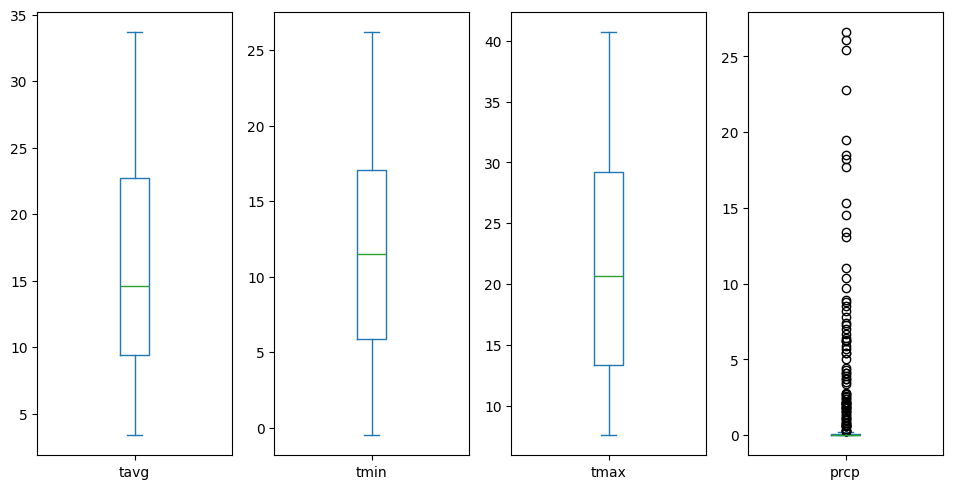

<Figure size 640x480 with 0 Axes>

In [36]:
df_tiempo2022.plot(kind='box', subplots=True, figsize=(12, 5), layout=(1, df_tiempo2022.shape[1]))
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

+ Los boxplots muestran distribuciones normales para las variables de temperatura sin anomalías preocupantes.
+ En precipitación (`prcp`), los valores atípicos son esperables ya que muchos días del año no llueve (valor 0) y ocasionalmente hay días con precipitaciones intensas.
+ No consideramos que existan anomalías que requieran tratamiento especial en este dataset meteorológico.

## 4. Análisis Descrptivo

En esta sección exploramos las características estadísticas y distribuciones de las variables en nuestro datasets limpio. El análisis descriptivo nos permite comprender la naturaleza de los datos mediante métricas de tendencia central, dispersión y visualizaciones de distribuciones, proporcionando la base para interpretaciones y análisis posteriores.

### 4.1 Métricas de estadística descriptiva

In [37]:
pd.set_option('display.float_format', '{:.2f}'.format) # Para fijar 2 decimales en las tablas a continuacion
df_tiempo2022.drop(columns='time').describe(percentiles=[0.5])

,tavg,tmin,tmax,prcp
count,365.00,365.00,365.00,365.00
mean,16.50,11.97,22.08,1.33
std,8.06,6.89,9.28,3.89
min,3.40,-0.50,7.60,0.00
50%,14.60,11.50,20.70,0.00
max,33.70,26.20,40.70,26.60


### 4.2 Distribución de variables.

=== DISTRIBUCIONES DE VARIABLES METEOROLÓGICAS ===


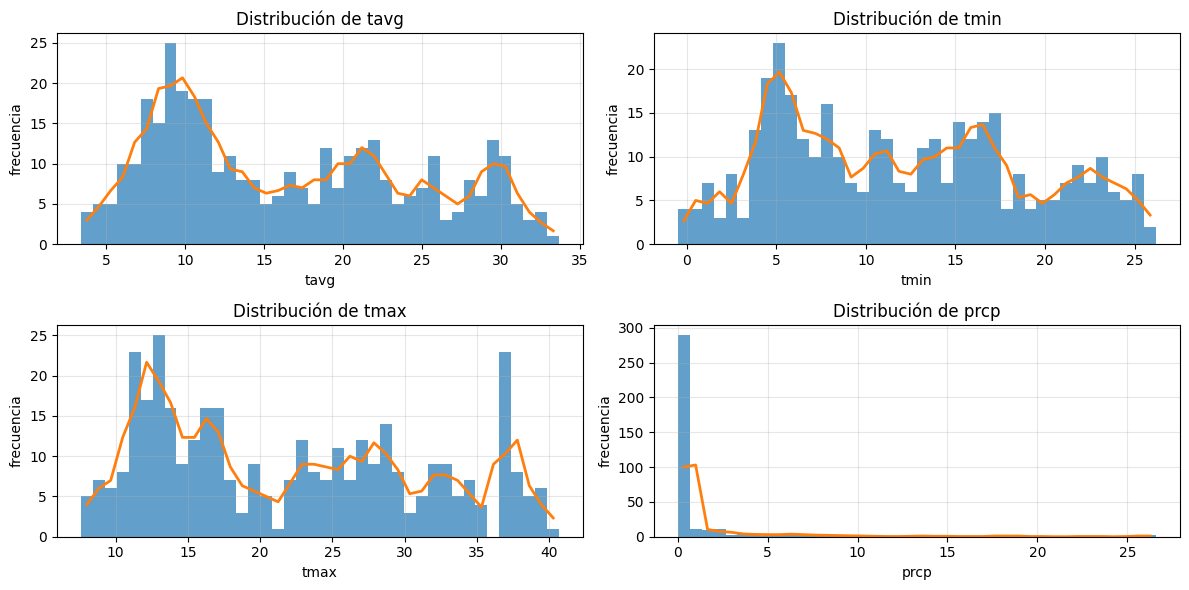

In [38]:
# Generar gráficos de distribución automáticamente
print("=== DISTRIBUCIONES DE VARIABLES METEOROLÓGICAS ===")
graficar_distribuciones(df_tiempo2022, columnas_excluir=['time'], bins=40)

### **Insights**

+ **Temperaturas medias:** Media anual de 16.5°C, mínima de 3.4°C y máxima de 33.7°C. La distribución muestra tres picos: invierno, estaciones intermedias y verano.

+ **Temperaturas mínimas:** Media de 11.97°C, mínima de -0.5°C y máxima de 26.2°C. La distribución es más uniforme que las medias.

+ **Temperaturas máximas:** Media de 22.08°C, mínima de 7.6°C y máxima de 40.7°C. La distribución presenta varios picos reflejando la variabilidad estacional.

+ **Precipitaciones:** La media fue muy baja, solo 1.33 mm diarios, confirmando el carácter seco de Madrid. La gráfica es extremadamente sesgada: Cerca de 300 días sin lluvia (0 mm) y pocos días con precipitación significativa, llegando al máximo de 26.6 mm.

## 5. Ingeniería de variables


En esta sección se crean variables categóricas que facilitarán el análisis posterior al unir con los datos de Bicimad y tráfico. La categorización permite agrupar los días según condiciones meteorológicas similares, lo que será útil para analizar patrones de uso del transporte público.

### Categorización de Temperatura

Para la temperatura media (`tavg`) se utilizarán 4 categorías basadas en cuartiles (percentiles 25%, 50%, 75%), lo que garantiza una distribución equilibrada por categoría:

- **Fría**: Temperaturas ≤ Q25
- **Fresca**: Temperaturas entre Q25 y Q50  
- **Templada**: Temperaturas entre Q50 y Q75
- **Calurosa**: Temperaturas > Q75

La funcion `categorizar` permite la creación de una nueva variable que distribuye por cuartiles la variable que se pase como argumento entre las clases que se le especifiquen. La selección de cuartiles es uniforme, depende del número de clases que se especifiquen.

### Categorización de Precipitación

Para la precipitación (`prcp`) el enfoque es diferente debido a la naturaleza sesgada de los datos (muchos días sin lluvia):

- **Sin lluvia**: Días con precipitación exactamente 0 mm (~265 días)
- **Lluvia ligera**: Primera mitad de días lluviosos (percentil 50% de valores > 0)
- **Lluvia intensa**: Segunda mitad de días lluviosos (> percentil 50% de valores > 0)

No se pudo utilizar la funcion `categorizar` debido al método utilizado. Por eso se construyó `categorizar_precipitacion`

In [39]:
# Categorizar temperatura media (4 categorías)
df_tiempo2022['categoria_temp'] = categorizar(df_tiempo2022['tavg'],
                                              'Fría', 'Fresca', 'Templada', 'Calurosa')

# Categorizar precipitación (3 categorías: Sin lluvia + 2 para días lluviosos)
df_tiempo2022['categoria_lluvia'] = categorizar_precipitacion(df_tiempo2022['prcp'])

### Visualización de Variables Categóricas

Las siguientes gráficas muestran la distribución de las nuevas variables categóricas creadas. Los números sobre cada barra indican la cantidad exacta de días en cada categoría, verificando que la categorización ha funcionado correctamente.

=== DISTRIBUCIONES DE VARIABLES CATEGÓRICAS ===


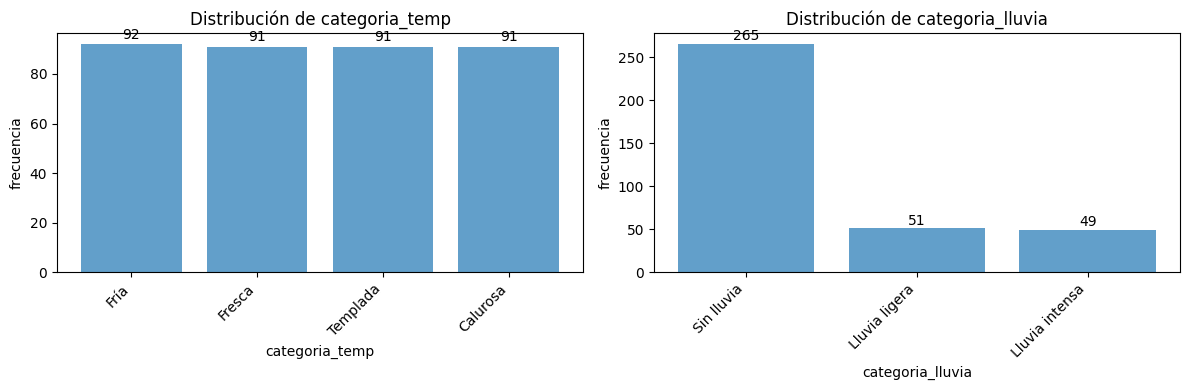

In [40]:
# Generar gráficos de variables categóricas automáticamente  
print("=== DISTRIBUCIONES DE VARIABLES CATEGÓRICAS ===")
orden_categorias = {
    'categoria_temp': ['Fría', 'Fresca', 'Templada', 'Calurosa'],
    'categoria_lluvia': ['Sin lluvia', 'Lluvia ligera', 'Lluvia intensa']
}
graficar_categoricas_con_etiquetas(df_tiempo2022, ['categoria_temp', 'categoria_lluvia'], orden_categorias)

### Resultados de la categorizacion

+ En la temperatura, resulta una distribución equilibrada de 91 días por categoría.
+ En las precipitaciones, la distribución refleja que el 72% de los días del año 2022 no se produjeron lluvias.


## Guardar los datos limpios en un nuevo CSV

In [ ]:
df_tiempo2022.rename(columns={'time': 'Dia'}, inplace=True)
df_tiempo2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              365 non-null    datetime64[ns]
 1   tavg              365 non-null    Float64       
 2   tmin              365 non-null    Float64       
 3   tmax              365 non-null    Float64       
 4   prcp              365 non-null    Float64       
 5   categoria_temp    365 non-null    category      
 6   categoria_lluvia  365 non-null    category      
dtypes: Float64(4), category(2), datetime64[ns](1)
memory usage: 16.9 KB


In [42]:
df_tiempo2022.to_csv('2022_meteostat_CleanData/meteo_madrid_2022_limpio.csv', index=False)

## Resumen Final

Este análisis exploratorio ha extraído y procesado exitosamente los datos meteorológicos oficiales de Madrid 2022 mediante la API de Meteostat, creando un dataset estructurado y listo para análisis integrados.

**Resultados del EDA:**
- **Dataset final**: 365 días con 7 variables meteorológicas (4 numéricas + 3 categóricas)
- **Calidad de datos**: Dataset completo sin valores faltantes, duplicados ni anomalías
- **Variables clave**: Temperaturas (media, mínima, máxima) y precipitación con categorización inteligente
- **Ingeniería de variables**: Categorización por cuartiles para temperatura y tratamiento especial para precipitación

**Características climáticas de Madrid 2022:**
- Temperatura media anual: 16.5°C (rango: 3.4°C - 33.7°C)
- Precipitaciones: Muy bajas con 1.33 mm/día promedio (72% días sin lluvia)

**Capacidades analíticas obtenidas:**
- Variables categóricas balanceadas para análisis de impacto climático
- Granularidad diaria perfecta para cruces con datos de BiciMad y tráfico
- Base sólida para identificar patrones de movilidad según condiciones meteorológicas

El dataset limpio permitirá análisis del impacto climático en el transporte urbano madrileño con alta precisión temporal.